# Analysis of the data base

The data base is composed of all matches of 5 seasons : from 2020/2021 to 2024/2025 will be used to test our model

Source : understat.com

In [32]:
import matplotlib.pyplot as plt
import pandas as pd 
import numpy as np 
import seaborn as sns

In [33]:
df = pd.read_excel('/Users/baptistesmac/Documents/Formation finance/ML ligue 1/data/raw/understat2_ligue1_matches.xlsx')
df.head()

,season,date,home_team,away_team,home_goals,away_goals,home_xg,away_xg,home_shots,away_shots,home_shots_on_target,away_shots_on_target,home_ppda,away_ppda,home_deep,away_deep,Result
0,2016/17,2016-08-12,SC Bastia,Paris Saint Germain,0,1,0.8284,0.6649,10,9,0,6,12.6667,4.1154,0,3,A
1,2016/17,2016-08-12,Monaco,Guingamp,2,2,2.4964,0.6990,18,9,4,5,2.6053,12.2857,9,2,D
2,2016/17,2016-08-13,Bordeaux,Saint-Etienne,3,2,1.1659,1.5013,11,14,6,5,11.5000,5.0313,3,7,H
3,2016/17,2016-08-13,Caen,Lorient,3,2,2.2728,1.9864,16,8,7,2,8.9583,12.6667,8,7,H
4,2016/17,2016-08-13,Metz,Lille,3,2,2.3171,1.8778,7,17,3,4,11.6667,15.2143,4,4,H


In [34]:
df.info()
print(df.isnull().sum())
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3412 entries, 0 to 3411
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   season                3412 non-null   object        
 1   date                  3412 non-null   datetime64[ns]
 2   home_team             3412 non-null   object        
 3   away_team             3412 non-null   object        
 4   home_goals            3412 non-null   int64         
 5   away_goals            3412 non-null   int64         
 6   home_xg               3412 non-null   float64       
 7   away_xg               3412 non-null   float64       
 8   home_shots            3412 non-null   int64         
 9   away_shots            3412 non-null   int64         
 10  home_shots_on_target  3412 non-null   int64         
 11  away_shots_on_target  3412 non-null   int64         
 12  home_ppda             3412 non-null   float64       
 13  away_ppda         

,date,home_goals,away_goals,home_xg,away_xg,home_shots,away_shots,home_shots_on_target,away_shots_on_target,home_ppda,away_ppda,home_deep,away_deep
count,3412,3412.000000,3412.000000,3412.000000,3412.000000,3412.000000,3412.000000,3412.000000,3412.000000,3412.000000,3412.000000,3412.000000,3412.000000
mean,2021-03-24 18:22:22.086752768,1.512896,1.210434,1.535249,1.220226,13.349941,11.098769,4.676729,3.917644,11.683684,13.059060,6.052462,5.086460
min,2016-08-12 00:00:00,0.000000,0.000000,0.014500,0.000000,1.000000,0.000000,0.000000,0.000000,2.370400,2.388900,0.000000,0.000000
25%,2018-10-20 00:00:00,1.000000,0.000000,0.864100,0.613375,10.000000,8.000000,3.000000,2.000000,7.666700,8.377075,3.000000,2.000000
50%,2021-03-14 00:00:00,1.000000,1.000000,1.370950,1.069550,13.000000,11.000000,4.000000,4.000000,10.384050,11.421100,5.000000,4.000000
75%,2023-08-12 00:00:00,2.000000,2.000000,2.016350,1.640725,16.000000,14.000000,6.000000,5.000000,14.139800,15.827900,8.000000,7.000000
max,2026-03-22 00:00:00,9.000000,7.000000,5.942400,5.067900,37.000000,31.000000,15.000000,15.000000,66.833300,85.142900,30.000000,30.000000
std,NaN,1.292519,1.154562,0.908507,0.798251,4.926792,4.519015,2.457641,2.318135,6.009660,7.005715,4.014179,3.707002


Variables : 

- **home_goals** / **away_goals** : number of goals scored by the home / away team
- **home_xg** / **away_xg** : expected goals — sum of the scoring probability of each shot, measures the quality of chances created
- **home_shots** / **away_shots** : total number of shots attempted
- **home_shots_on_target** / **away_shots_on_target** : number of shots on target (that would have required a save from the goalkeeper)
- **home_ppda** / **away_ppda** : Passes Per Defensive Action - measures pressing intensity ; the lower the value, the higher and more intense the press
- **home_deep** / **away_deep** : number of passes in the final third — proxy for pressure applied near the opponent's goal

## 1. Analysis of home advantage

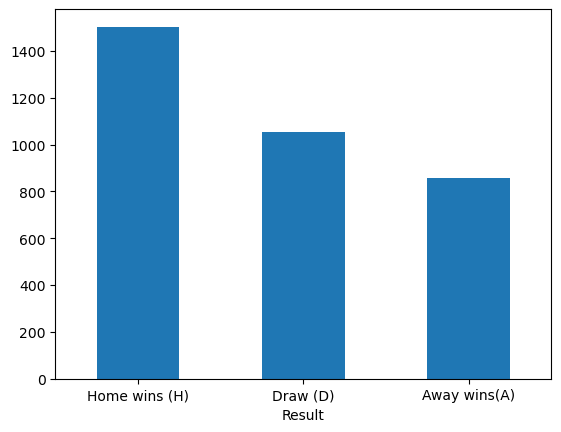

In [35]:
counts = df["Result"].value_counts()
counts.plot(kind='bar')
plt.xticks(ticks=[0,1,2], labels=['Home wins (H)', 'Draw (D)', 'Away wins(A)'], rotation=0)
plt.show()

In [36]:
print("% "+"of Home wins : "+str(round(counts["H"]/len(df["Result"])*100))+"%")
print("% "+"of Away wins : "+str(round(counts["A"]/len(df["Result"])*100))+"%")
print("% "+"of Draws : "+str(round(counts["D"]/len(df["Result"])*100))+"%")

% of Home wins : 44%
% of Away wins : 31%
% of Draws : 25%


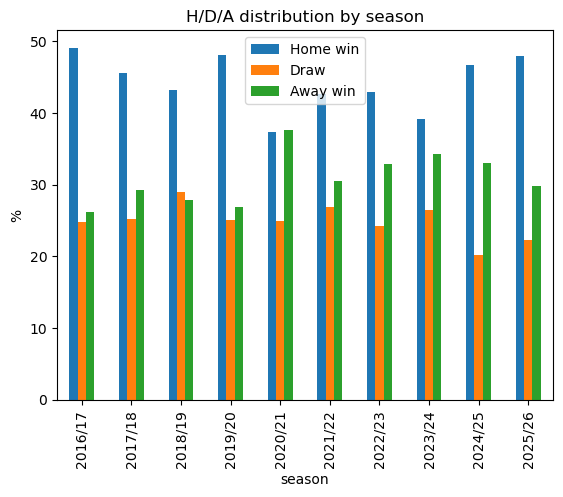

In [37]:
hda_by_season = df.groupby("season")["Result"].value_counts(normalize=True).unstack()*100
hda_by_season[["H", "D", "A"]].plot(kind="bar")
plt.title("H/D/A distribution by season")
plt.ylabel("%")
plt.legend(["Home win", "Draw", "Away win"])

44% home wins vs. 31% away wins — the home-field advantage is significant in Ligue 1. The goal gap (1.50 vs. 1.31 per match) is more moderate, suggesting that the advantage primarily manifests in tight matches. (seen later)

### Rolling mean (of 100 matches days) of home wins % during the five seasons : 

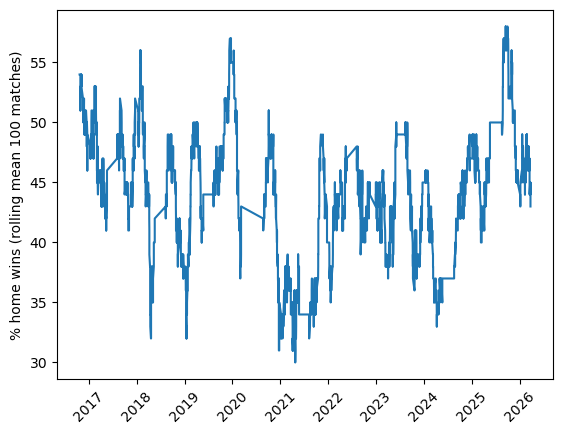

In [38]:
df['is_home_win'] = (df['Result'] == 'H').astype(int) #Create a column with 1 if home win
df['rolling_home_win'] = df['is_home_win'].rolling(window=100).mean() * 100
plt.ylabel("%"+" home wins (rolling mean 100 matches)")
plt.plot(df["date"],df['rolling_home_win'])
plt.xticks(rotation=45)
plt.show()


The home win rate fluctuates between 30% and 55%. A notable drop is observed in early 2021 (COVID-19 matches played behind closed doors). The return of fans coincides with a gradual recovery.

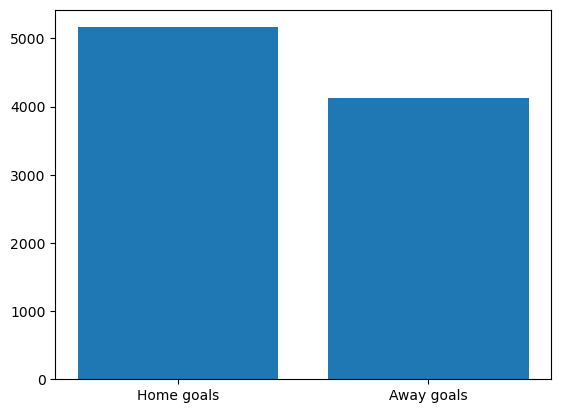

In [39]:
counts =[np.sum(df["home_goals"]),np.sum(df["away_goals"])]
plt.bar([0, 1], counts)
plt.xticks(ticks=[0,1], labels=['Home goals', 'Away goals'], rotation=0)
plt.show()

In [40]:
print("% "+"of Home goals per game : "+str(round(np.sum(df["home_goals"])/len(df["Result"]),2)))
print("% "+"of Away goals per game : "+str(round(np.sum(df["away_goals"])/len(df["Result"]),2)))

% of Home goals per game : 1.51
% of Away goals per game : 1.21


The home advantage is clearer in win rate (+17pp) than in goals per game (+0.19), suggesting that home teams convert close games more effectively rather than dominating scorelines.

## 2. The xG

Let's scatter the actual goals w/ respect to xG

/var/folders/wg/p4b819hd79d9_9zf2ts8_wcw0000gn/T/ipykernel_42006/1969410532.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_goals = df.groupby('xg_bin')['home_goals'].mean()


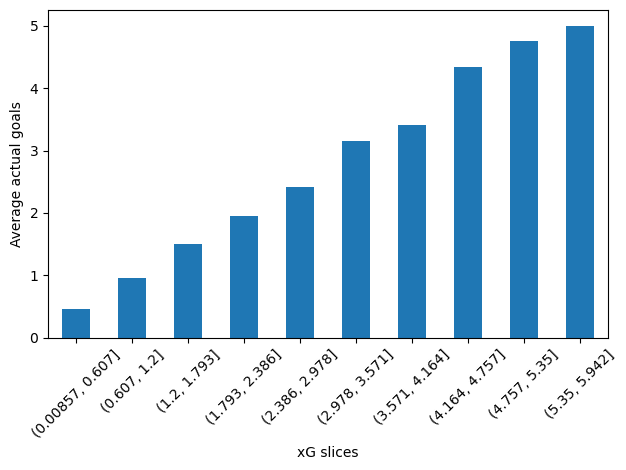

In [41]:
df['xg_bin'] = pd.cut(df['home_xg'], bins=10) # We cut home_xg column in 10 slices
avg_goals = df.groupby('xg_bin')['home_goals'].mean()
avg_goals.plot(kind='bar')
plt.xlabel('xG slices')
plt.ylabel('Average actual goals')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

The relationship between xG and actual goals is quasi-linear, confirming the relevance of xG as a predictive feature. xG effectively captures the quality of chances created.

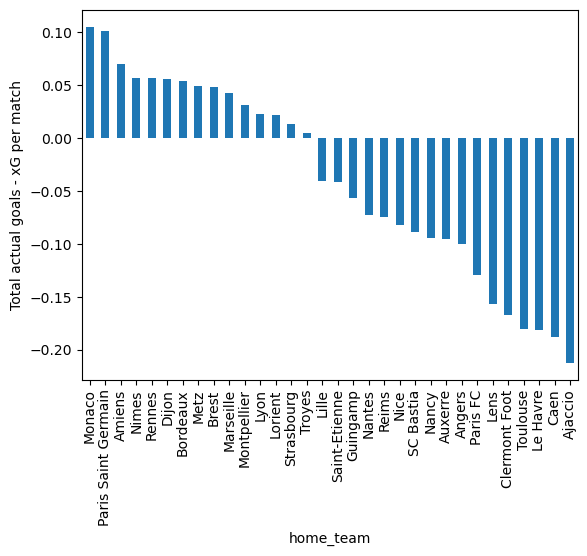

In [42]:
home = df.groupby("home_team")[["home_goals", "home_xg"]].sum()
home["nbr matches"] = df["home_team"].value_counts()
home.columns = ["goals", "xg","nbr_matches"]

away = df.groupby("away_team")[["away_goals", "away_xg"]].sum()
away["nbr_matches"] = df["away_team"].value_counts()
away.columns = ["goals", "xg","nbr_matches"]

team_stats = home.add(away, fill_value=0)
team_stats["diff"] = (team_stats["goals"] - team_stats["xg"])
team_stats["diff_per_match"] = team_stats["diff"] / team_stats["nbr_matches"]

team_stats.sort_values("diff_per_match", ascending=False)["diff_per_match"].plot(kind='bar')
plt.ylabel('Total actual goals - xG per match')
plt.xticks(rotation=90)
plt.show()



Monaco and PSG are overperforming their xG (quality finishers or luck). Ajaccio and Caen are underperforming (regression to the mean expected). This differential is a valuable feature for identifying teams likely to regress.

## 3. Other metrics distribution

Let's show the distribution of other metrics to have an idea of their value 

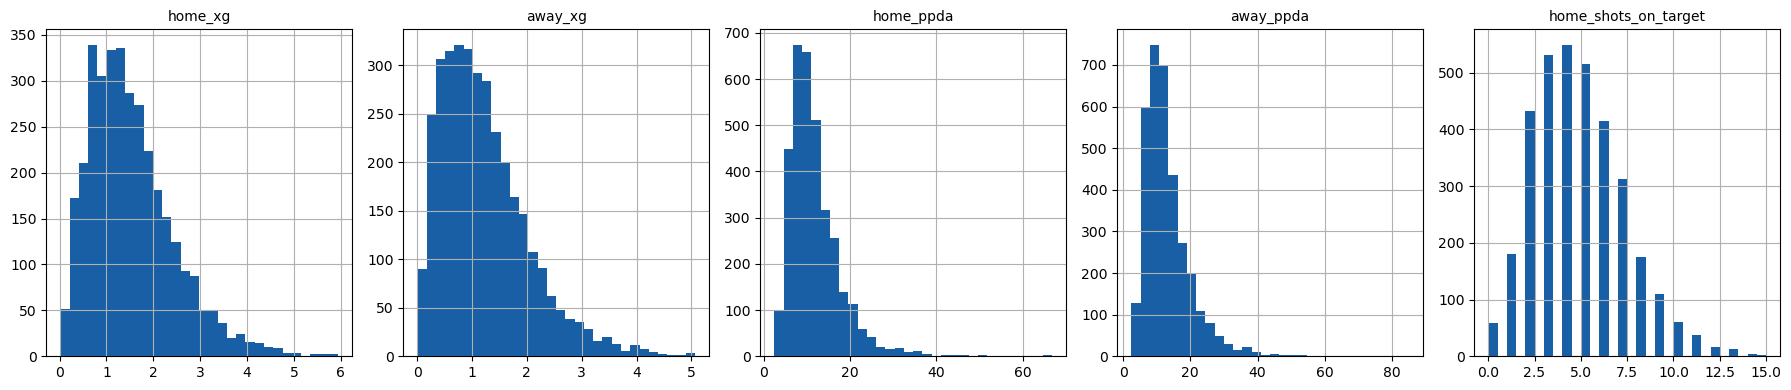

In [43]:
features = ['home_xg', 'away_xg', 'home_ppda', 'away_ppda', 'home_shots_on_target']

fig, axes = plt.subplots(1, 5, figsize=(18, 4))

for ax, col in zip(axes, features):
    df[col].hist(bins=30, ax=ax, color='#185FA5', edgecolor='none')
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'PPDA vs xG')

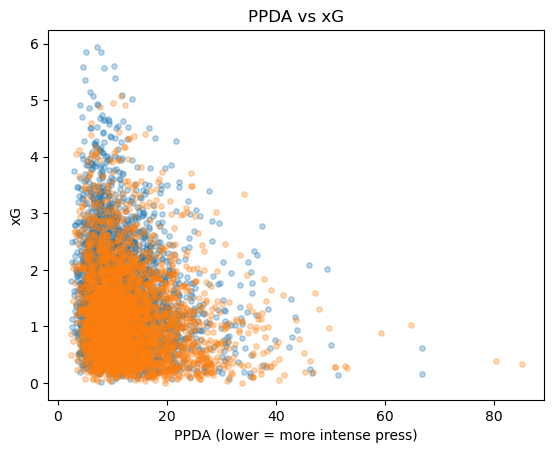

In [44]:
plt.scatter(df['home_ppda'], df['home_xg'], alpha=0.3, s=15, label='Home')
plt.scatter(df['away_ppda'], df['away_xg'], alpha=0.3, s=15, label='Away')
plt.xlabel('PPDA (lower = more intense press)')
plt.ylabel('xG')
plt.title('PPDA vs xG')

## 4. Correlation Matrix

Let's compute the correlation for all our metrics

In [45]:
cols = [
    'home_goals', 'away_goals',
    'home_xg', 'away_xg',
    'home_shots', 'away_shots',
    'home_shots_on_target', 'away_shots_on_target',
    'home_ppda', 'away_ppda',
    'home_deep', 'away_deep'
]

corr_matrix = df[cols].corr()
print(corr_matrix)

                      home_goals  away_goals   home_xg   away_xg  home_shots  \
home_goals              1.000000   -0.093367  0.626307 -0.143646    0.257703   
away_goals             -0.093367    1.000000 -0.141759  0.633345   -0.068200   
home_xg                 0.626307   -0.141759  1.000000 -0.199141    0.598864   
away_xg                -0.143646    0.633345 -0.199141  1.000000   -0.197975   
home_shots              0.257703   -0.068200  0.598864 -0.197975    1.000000   
away_shots             -0.086173    0.307812 -0.188763  0.632804   -0.299538   
home_shots_on_target    0.584182   -0.079648  0.662131 -0.155083    0.649688   
away_shots_on_target   -0.104977    0.584068 -0.159727  0.676839   -0.179369   
home_ppda              -0.069656    0.124804 -0.188728  0.287689   -0.325909   
away_ppda               0.146401   -0.073201  0.258005 -0.193178    0.313001   
home_deep               0.284117   -0.093535  0.500379 -0.174411    0.541560   
away_deep              -0.104098    0.27

<Axes: >

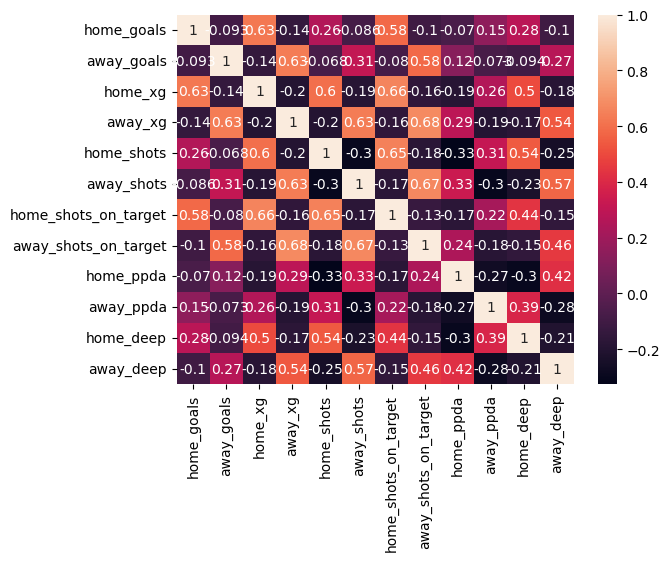

In [46]:
sns.heatmap(corr_matrix,annot=True)

The variables most highly correlated with goals are xG (0.63) and shots on target (0.58). PPDA and deep completions show weaker but non-negligible correlations (~0.1-0.27). Note: shots and xG are highly correlated with each other (0.62); this multicollinearity will need to be addressed during modeling.